# Time Series Data

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.tsa.stattools as sts
import seaborn as sns
sns.set_style('darkgrid')

In [17]:
raw_data = pd.read_csv("data/Index2018.csv")
raw_data.head()

,date,spx,dax,ftse,nikkei
0,07/01/1994,469.90,2224.95,3445.98,18124.01
1,10/01/1994,475.27,2225.00,3440.58,18443.44
2,11/01/1994,474.13,2228.10,3413.77,18485.25
3,12/01/1994,474.17,2182.06,3372.02,18793.88
4,13/01/1994,472.47,2142.37,3360.01,18577.26


In [18]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6269 entries, 0 to 6268
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    6269 non-null   str    
 1   spx     6269 non-null   float64
 2   dax     6269 non-null   float64
 3   ftse    6269 non-null   float64
 4   nikkei  6269 non-null   float64
dtypes: float64(4), str(1)
memory usage: 306.2 KB


In [19]:
df_copy = raw_data.copy()

In [20]:
df_copy.head()

,date,spx,dax,ftse,nikkei
0,07/01/1994,469.90,2224.95,3445.98,18124.01
1,10/01/1994,475.27,2225.00,3440.58,18443.44
2,11/01/1994,474.13,2228.10,3413.77,18485.25
3,12/01/1994,474.17,2182.06,3372.02,18793.88
4,13/01/1994,472.47,2142.37,3360.01,18577.26


In [21]:
df_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
spx,6269.0,1288.127542,487.586473,438.92,990.671905,1233.42,1459.987747,2872.867839
dax,6269.0,6080.063363,2754.361032,1911.70,4069.350000,5773.34,7443.070000,13559.600000
ftse,6269.0,5422.713545,1145.572428,2876.60,4486.100000,5662.43,6304.250000,7778.637689
nikkei,6269.0,14597.055700,4043.122953,7054.98,10709.290000,15028.17,17860.470000,24124.150000


In [22]:
df_copy.isnull().sum()  

date      0
spx       0
dax       0
ftse      0
nikkei    0
dtype: int64

In [25]:
# convert date to datetime
df_copy['date'] = pd.to_datetime(df_copy['date'], format='%d/%m/%Y')
df_copy = df_copy.set_index('date')
df_copy.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 6269 entries, 1994-01-07 to 2018-01-29
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   spx     6269 non-null   float64
 1   dax     6269 non-null   float64
 2   ftse    6269 non-null   float64
 3   nikkei  6269 non-null   float64
dtypes: float64(4)
memory usage: 244.9 KB


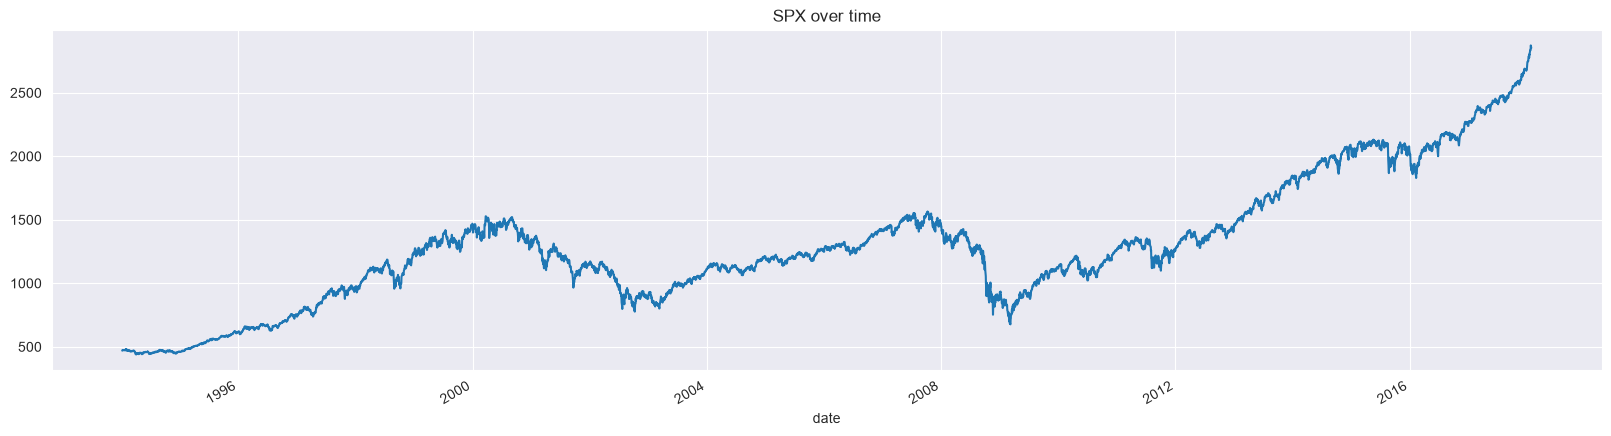

In [26]:
df_copy.spx.plot(title="SPX over time", figsize=(20, 5))
plt.show()

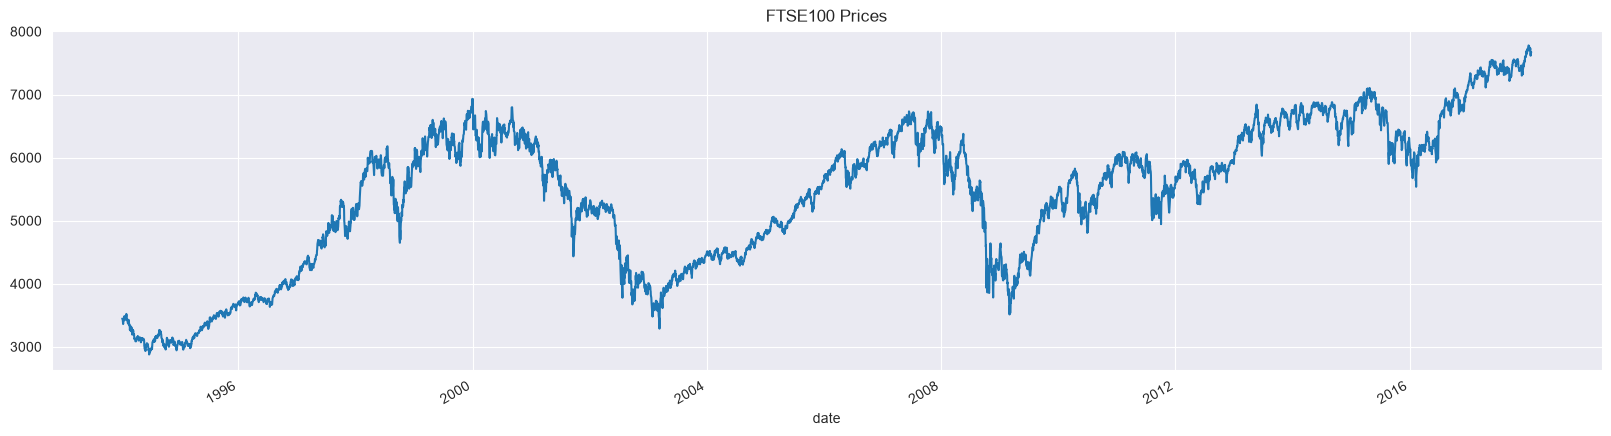

In [27]:
df_copy.ftse.plot(title="FTSE100 Prices", figsize=(20, 5))
plt.show()

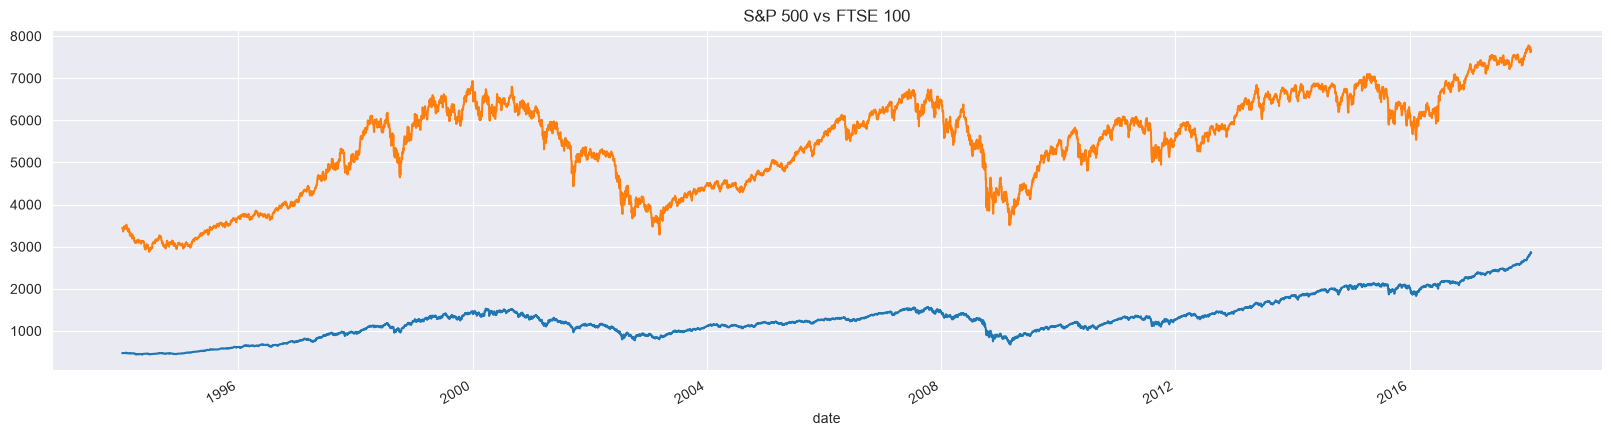

In [28]:
df_copy.spx.plot(figsize=(20,5), title="S&P 500 Prices")
df_copy.ftse.plot(figsize=(20,5), title="FTSE 100 Prices")
plt.title("S&P 500 vs FTSE 100")
plt.show()

## Setting the Frequency

In [30]:
df_copy = df_copy.asfreq("D")

In [31]:
df_copy.head()

,spx,dax,ftse,nikkei
date,,,,
1994-01-07,469.90,2224.95,3445.98,18124.01
1994-01-08,NaN,NaN,NaN,NaN
1994-01-09,NaN,NaN,NaN,NaN
1994-01-10,475.27,2225.00,3440.58,18443.44
1994-01-11,474.13,2228.10,3413.77,18485.25


In [33]:
df_copy = df_copy.asfreq("B")

In [34]:
df_copy.head()

,spx,dax,ftse,nikkei
date,,,,
1994-01-07,469.90,2224.95,3445.98,18124.01
1994-01-10,475.27,2225.00,3440.58,18443.44
1994-01-11,474.13,2228.10,3413.77,18485.25
1994-01-12,474.17,2182.06,3372.02,18793.88
1994-01-13,472.47,2142.37,3360.01,18577.26


## Handling Missing Values

In [35]:
df_copy.isnull()

,spx,dax,ftse,nikkei
date,,,,
1994-01-07,False,False,False,False
1994-01-10,False,False,False,False
1994-01-11,False,False,False,False
1994-01-12,False,False,False,False
1994-01-13,False,False,False,False
...,...,...,...,...
2018-01-23,False,False,False,False
2018-01-24,False,False,False,False
2018-01-25,False,False,False,False


In [36]:
df_copy.isnull().sum()  

spx       8
dax       8
ftse      8
nikkei    8
dtype: int64

In [38]:
df_copy.spx = df_copy.spx.ffill()

In [39]:
df_copy.isnull().sum()

spx       0
dax       8
ftse      8
nikkei    8
dtype: int64

In [40]:
df_copy.ftse = df_copy.ftse.bfill()

In [41]:
df_copy.isnull().sum()

spx       0
dax       8
ftse      0
nikkei    8
dtype: int64

In [42]:
df_copy.dax = df_copy.dax.ffill().bfill()

In [43]:
df_copy.isnull().sum()

spx       0
dax       0
ftse      0
nikkei    8
dtype: int64

In [44]:
df_copy.nikkei = df_copy.nikkei.ffill()

In [45]:
df_copy.isnull().sum()

spx       0
dax       0
ftse      0
nikkei    0
dtype: int64

### Simplifying the dataset

In [46]:
df_copy['market_value'] = df_copy.spx

In [47]:
df_copy.describe().T    

,count,mean,std,min,25%,50%,75%,max
spx,6277.0,1288.642547,487.868210,438.92,992.715221,1233.761241,1460.250000,2872.867839
dax,6277.0,6083.381061,2755.563853,1911.70,4070.460000,5774.260000,7445.560000,13559.600000
ftse,6277.0,5423.690398,1145.568370,2876.60,4487.880000,5663.300000,6304.630175,7778.637689
nikkei,6277.0,14597.672753,4043.795272,7054.98,10701.130000,15030.510000,17860.470000,24124.150000
market_value,6277.0,1288.642547,487.868210,438.92,992.715221,1233.761241,1460.250000,2872.867839


In [48]:
del df_copy['ftse']

In [49]:
df_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
spx,6277.0,1288.642547,487.868210,438.92,992.715221,1233.761241,1460.25,2872.867839
dax,6277.0,6083.381061,2755.563853,1911.70,4070.460000,5774.260000,7445.56,13559.600000
nikkei,6277.0,14597.672753,4043.795272,7054.98,10701.130000,15030.510000,17860.47,24124.150000
market_value,6277.0,1288.642547,487.868210,438.92,992.715221,1233.761241,1460.25,2872.867839


In [50]:
del df_copy['spx'], df_copy['dax'], df_copy['nikkei']

In [51]:
df_copy.describe()

,market_value
count,6277.000000
mean,1288.642547
std,487.868210
min,438.920000
25%,992.715221
50%,1233.761241
75%,1460.250000
max,2872.867839


## Splitting the data

In [52]:
size = int(len(df_copy )*0.8)

In [53]:
df = df_copy.iloc[:size]

In [54]:
df_test = df_copy.iloc[size:]

In [55]:
df.tail()

,market_value
date,
2013-04-01,1562.173837
2013-04-02,1570.252238
2013-04-03,1553.686978
2013-04-04,1559.979316
2013-04-05,1553.278930


In [56]:
df_test.head()

,market_value
date,
2013-04-08,1563.071269
2013-04-09,1568.607909
2013-04-10,1587.731827
2013-04-11,1593.369863
2013-04-12,1588.854623


## Working with Time series
### Generating White Noise Data

In [57]:
wn = np.random.normal(
    loc = df['market_value'].mean(),
    scale = df['market_value'].std(),
    size = len(df)
)

In [58]:
df['wn'] = wn

In [59]:
df.describe()

,market_value,wn
count,5021.000000,5021.000000
mean,1091.651926,1089.341103
std,292.559287,292.894689
min,438.920000,-0.112061
25%,914.620000,890.053787
50%,1144.650000,1087.573533
75%,1316.280729,1289.987141
max,1570.252238,2176.644598


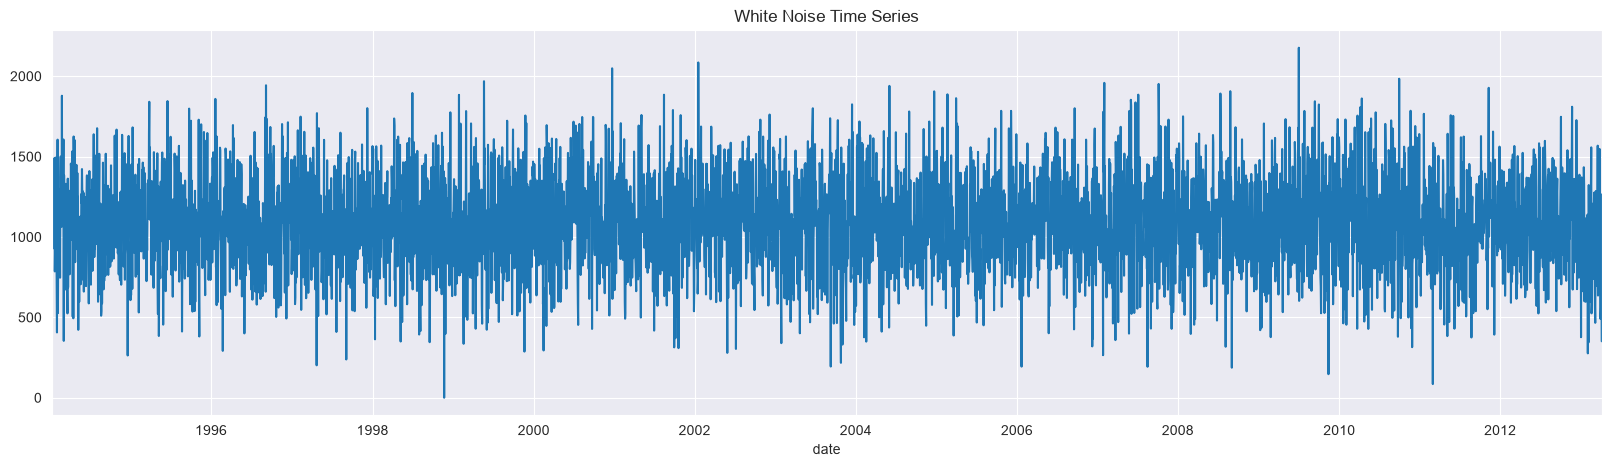

In [60]:
df.wn.plot(figsize=(20,5))
plt.title("White Noise Time Series")
plt.show()

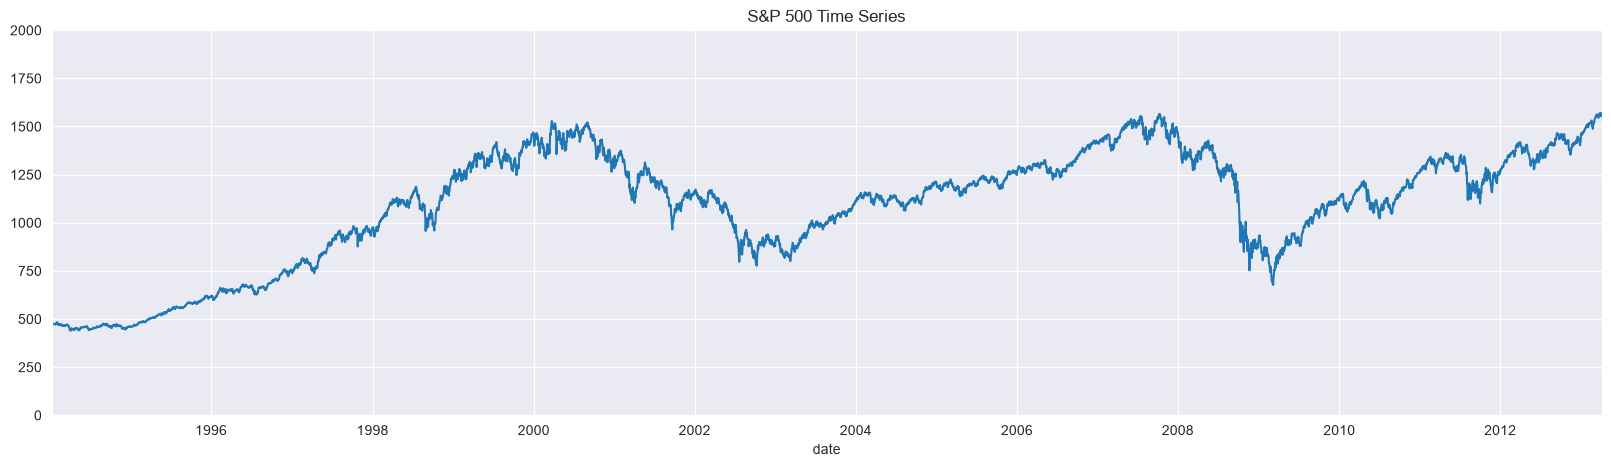

In [61]:
df.market_value.plot(figsize=(20,5))
plt.title("S&P 500 Time Series")
plt.ylim(0, 2000)
plt.show()

## Stationarity

In [68]:
adf_result = sts.adfuller(df.market_value)

print('ADF Statistic: %f' % adf_result[0])
print('p-value: %f' % adf_result[1])
print('ADF Result:', adf_result)

ADF Statistic: -1.736985
p-value: 0.412165
ADF Result: (-1.7369847452352436, 0.4121645696770623, 18, 5002, {'1%': np.float64(-3.431658008603046), '5%': np.float64(-2.862117998412982), '10%': np.float64(-2.567077669247375)}, np.float64(39904.880607487445))


/var/folders/2y/rw1f6sdn1_z84ny_s3mlv_1w0000gn/T/ipykernel_14489/273709560.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = sts.adfuller(df.market_value)


In [67]:
adf_result = sts.adfuller(df.wn)

print('ADF Statistic: %f' % adf_result[0])
print('p-value: %f' % adf_result[1])
print('ADF Result:', adf_result)


ADF Statistic: -71.150975
p-value: 0.000000
ADF Result: (-71.1509750313614, 0.0, 0, 5020, {'1%': np.float64(-3.431653316130827), '5%': np.float64(-2.8621159253018247), '10%': np.float64(-2.5670765656497516)}, np.float64(70825.27219114761))


/var/folders/2y/rw1f6sdn1_z84ny_s3mlv_1w0000gn/T/ipykernel_14489/15861525.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = sts.adfuller(df.wn)


## Seasonality

In [69]:
from statsmodels.tsa.seasonal import seasonal_decompose

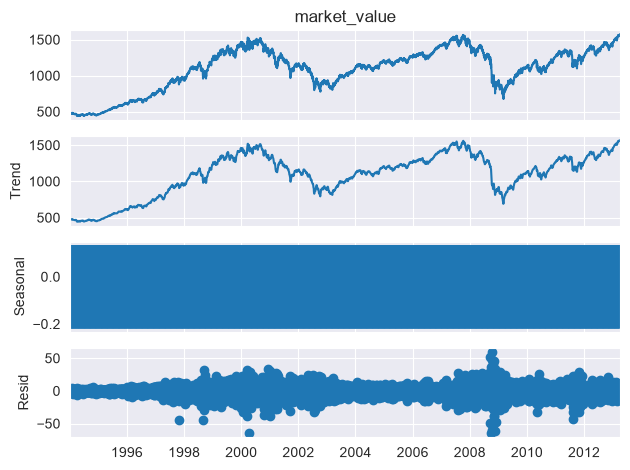

In [74]:
s_dec_additive = seasonal_decompose(df.market_value, model='additive')
s_dec_additive.plot()
plt.show()

## Making it Stationary

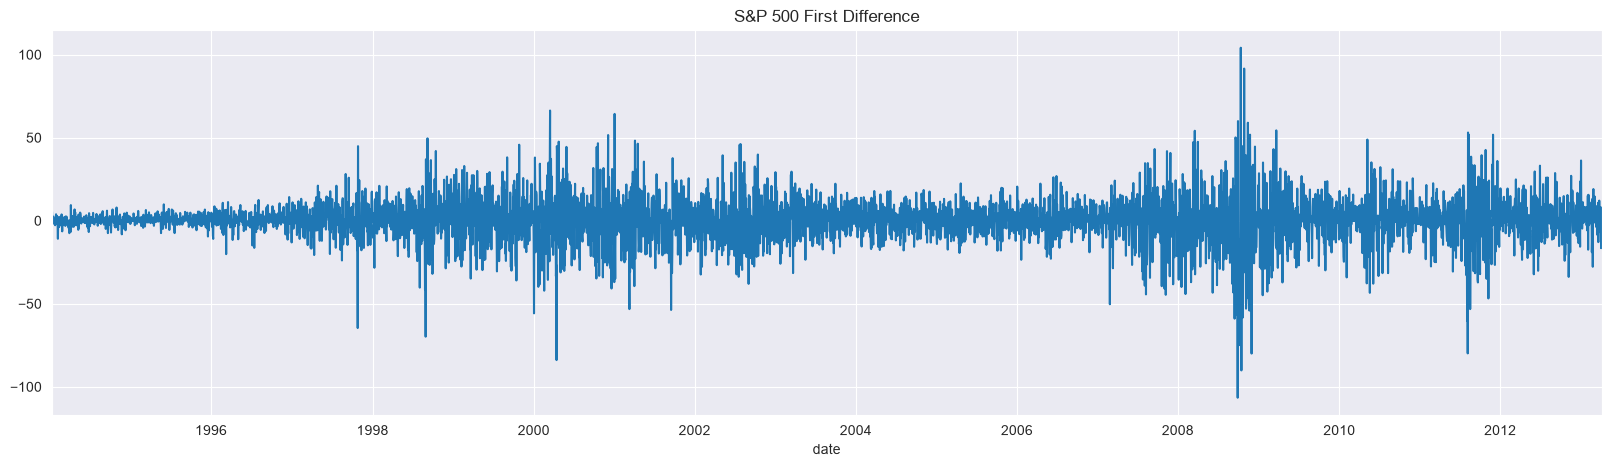

In [78]:
# making it stationary
df['market_value_diff'] = df.market_value.diff()
df['market_value_diff'].plot(figsize=(20,5))
plt.title("S&P 500 First Difference")
plt.show()

## Autocorrelation Function

In [75]:
import statsmodels.graphics.tsaplots as sgt

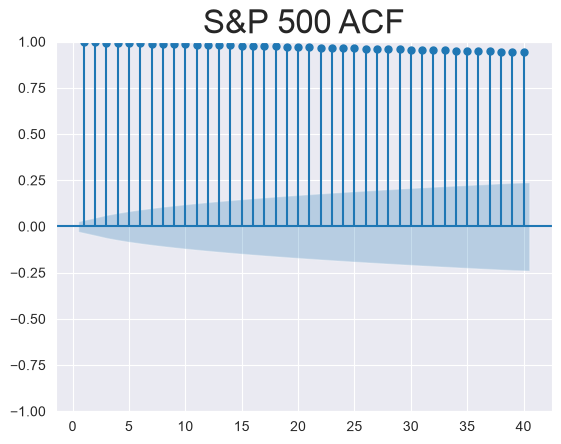

In [76]:
sgt.plot_acf(df.market_value, lags=40, zero=False)
plt.title("S&P 500 ACF", size=24)    
plt.show()

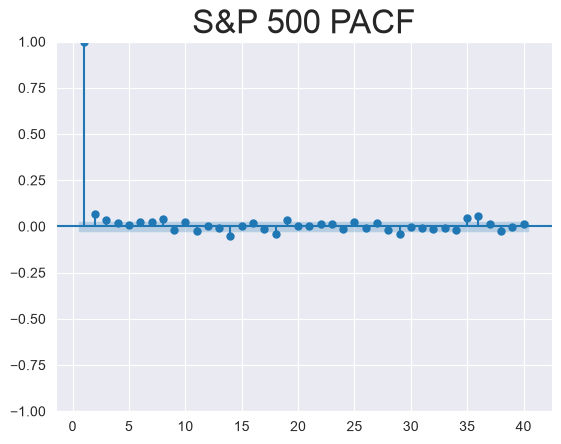

In [77]:
sgt.plot_pacf(df.market_value, lags=40, zero=False, method='ols')
plt.title("S&P 500 PACF", size=24)
plt.show()

## Choosing the correct model
- When conducting time-series analysis using supervised machine learning we need to know how to select the most appropriate model

- We usually start with a simple model and expand it as long as it follows several conditions.

- The new coefficients for the more complex model need to be significantly different from zero.

- If that does not hold true, the estimators for these parameters are essentially zero, therefore they don't help us estimate future values.

- This means they hold no predictive powers so we must omit them and revert back to the simpler models.

- We also want our model to be parsimonious or in other words as simple as possible generally we prefer using a simpler model to a more complicated one unless the latter provides significantly better predictions.

- To determine whether the predictions are significantly better we introduce a statistical test called the log likelihood ratio test

- The LLR test can only be applied to models with different degrees of freedom, thus when comparing several models with the same total number of required lags we need to compare the information criteria of each one

- The lower the coefficient, the less data the model requires to make accurate predictions.

- The two most prominent measurements of the kind are:

- AIC
- BIC
- Since we prefer simplicity, we opt for the model with lower AIC and BICcoefficients.

- if our model fits well, there should be no trend we have failed to account for therefore the residuals for the model should resemble white noise so we can conclude there is no other pattern we can account for without overtraining our model.

## The Autoregressive Integrated Moving Average (ARIMA)(1,1,1)

In [79]:
from statsmodels.tsa.arima.model import ARIMA

In [80]:
model_ar_1_1_1_ma_1 = ARIMA(df.market_value, order=(1,1,1))
results_ar_1_1_1_ma_1 = model_ar_1_1_1_ma_1.fit()
results_ar_1_1_1_ma_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:           market_value   No. Observations:                 5021
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -20072.331
Date:                Tue, 22 Sep 2026   AIC                          40150.663
Time:                        11:47:15   BIC                          40170.226
Sample:                    01-07-1994   HQIC                         40157.518
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6011      0.063      9.533      0.000       0.478       0.725
ma.L1         -0.6693      0.057    -11.723      0.000      -0.781      -0.557
sigma2       174.0008      1.764     98.631      0.000     170.543     177.458
===================================================================================
Ljung-Box (L1) (Q):                   0.19   Jarque-Bera (JB):              7333.43
Prob(Q):                              0.66   Prob(JB):                         0.00
Heteroskedasticity (H):               2.27   Skew:                            -0.44
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.86
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [84]:
# Forecast the same number of steps as the test set
n_steps = len(df_test)
forecast_obj = results_ar_1_1_1_ma_1.get_forecast(steps=n_steps)

# Extract predicted mean and confidence intervals
y_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

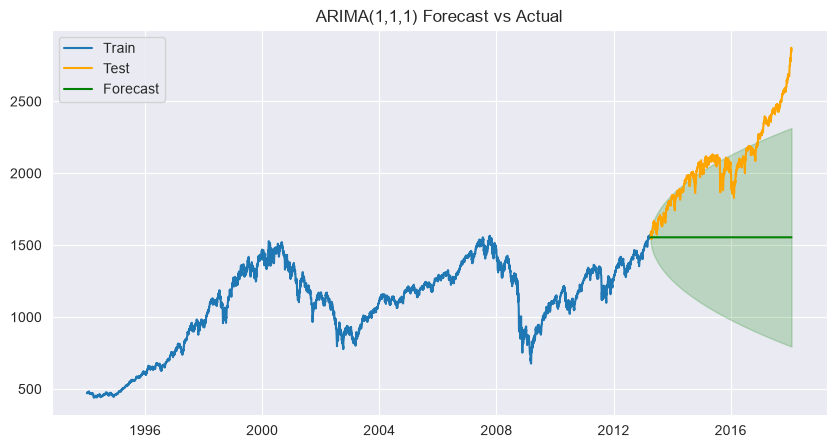

In [85]:
plt.figure(figsize=(10,5))
plt.plot(df.index, df.market_value, label='Train')
plt.plot(df_test.index, df_test.market_value, label='Test', color='orange')
plt.plot(y_pred.index, y_pred, label='Forecast', color='green')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='green', alpha=0.2)
plt.legend()
plt.title('ARIMA(1,1,1) Forecast vs Actual')
plt.show()

## Model Evaluation

In [86]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(df_test.market_value, y_pred)
rmse = np.sqrt(mean_squared_error(df_test.market_value, y_pred))

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE : 521.53
RMSE: 586.44


In [87]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(df['market_value'],
                       order=(1, 1, 1),           # non-seasonal (p,d,q)
                       seasonal_order=(1, 1, 1, 12),  # seasonal (P,D,Q,s) - s=12 for monthly data
                       enforce_stationarity=False,
                       enforce_invertibility=False)

results_sarima = model_sarima.fit()
print(results_sarima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                       market_value   No. Observations:                 5021
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood              -20008.692
Date:                            Tue, 22 Sep 2026   AIC                          40027.384
Time:                                    11:58:50   BIC                          40059.964
Sample:                                01-07-1994   HQIC                         40038.804
                                     - 04-05-2013                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5994      0.064      9.357      0.000       0.474       0.725
ma.L1         -0.6685      0.058   

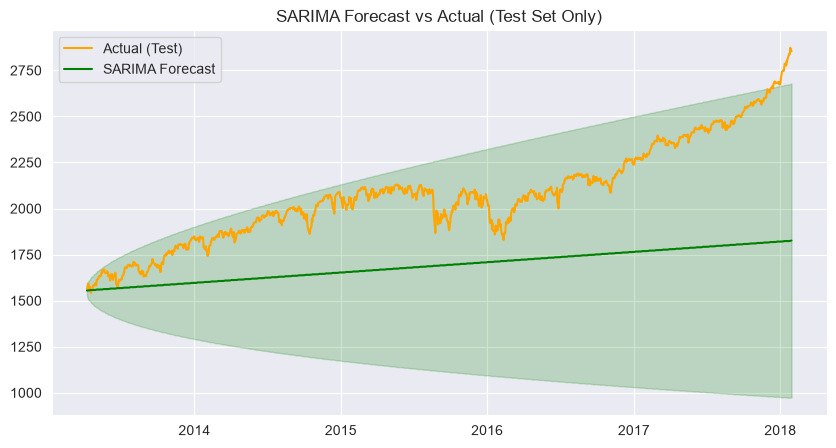

In [88]:
# Forecast the length of the test set
n_steps = len(df_test)
forecast_obj = results_sarima.get_forecast(steps=n_steps)

# Predicted values and confidence intervals
y_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

# Plot the test set vs forecast
plt.figure(figsize=(10,5))
plt.plot(df_test.index, df_test['market_value'], label='Actual (Test)', color='orange')
plt.plot(df_test.index, y_pred, label='SARIMA Forecast', color='green')
plt.fill_between(df_test.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='green', alpha=0.2)
plt.title('SARIMA Forecast vs Actual (Test Set Only)')
plt.legend()
plt.show()

In [89]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Actual values
y_true = df_test['market_value']

# Evaluation Metrics
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100  

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 386.0753
Root Mean Squared Error (RMSE): 433.8766
Mean Absolute Percentage Error (MAPE): 17.71%


## Auto ARIMA

In [101]:
# using auto ARIMA to get the best parameters
from pmdarima import auto_arima

# Fit auto ARIMA
auto_model = auto_arima(
    df_test['market_value'], 
    seasonal=False, 
    trace=True, 
    error_action='ignore', 
    suppress_warnings=True
)

# Print the best parameters
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=10320.347, Time=0.41 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=10317.019, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=10318.657, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=10318.632, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=10321.121, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=10316.386, Time=0.22 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=10318.385, Time=0.38 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=10318.385, Time=0.51 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=10319.219, Time=0.13 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=10319.375, Time=0.11 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=10323.376, Time=0.09 sec

Best model:  ARIMA(1,1,1)(0,0,0)[0] intercept
Total fit time: 2.049 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:       

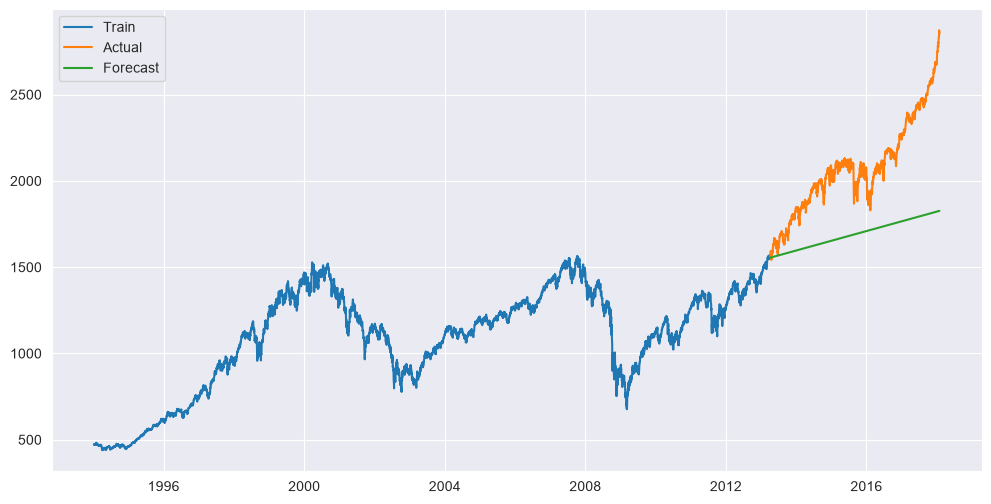

In [98]:
# fit the model on the TRAINING data only
auto_model.fit(df['market_value'])

# Forecast forward over the test period
y_pred_auto = auto_model.predict(n_periods=len(df_test))
y_pred_auto = pd.Series(y_pred_auto, index=df_test.index)

# Plot the results
plt.figure(figsize=(12,6))
plt.plot(df['market_value'], label='Train')
plt.plot(df_test['market_value'], label='Actual')
plt.plot(y_pred_auto, label='Forecast')
plt.legend()
plt.show()

## The Autoregressive Conditional Heteroskedasticity (ARCH) Model

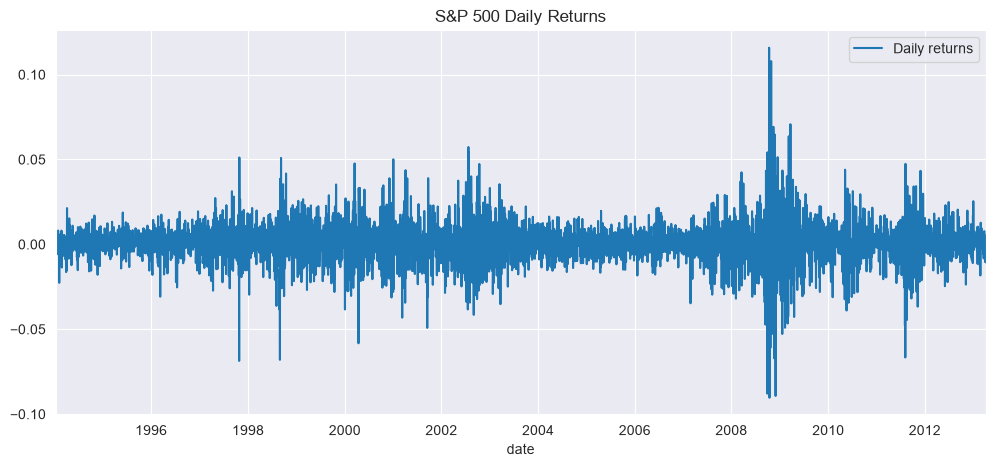

In [102]:
# Compute daily returns of the market value
returns = df['market_value'].pct_change().dropna()

plt.figure(figsize=(12, 5))
returns.plot(label='Daily returns')
plt.title('S&P 500 Daily Returns')
plt.legend()
plt.show()

**Insights:** The returns fluctuate around zero and look stationary compared with the raw price series. Notice the *volatility clustering* — big swings (e.g. around 2008) are followed by more big swings, so the variance is clearly not constant over time.

In [103]:
# A stationary mean and volatility clustering are signs that an ARCH model is appropriate.
# Test for ARCH effects using the Ljung-Box test on the SQUARED returns.
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(returns ** 2, lags=10, return_df=True)
print(lb_test)

        lb_stat      lb_pvalue
1    204.430902   2.254039e-46
2    811.005980  7.803492e-177
3    988.866729  4.680212e-214
4   1269.589325  1.304662e-273
5   1728.894106   0.000000e+00
6   2097.335930   0.000000e+00
7   2538.408311   0.000000e+00
8   2787.860293   0.000000e+00
9   3176.144409   0.000000e+00
10  3472.697648   0.000000e+00


**Insights:** Every p-value is well below 0.05, so we reject the null hypothesis of *no autocorrelation* in the squared returns. This confirms the presence of ARCH effects and justifies fitting an ARCH model.

### Fitting the ARCH model

In [119]:
from arch import arch_model

# ARCH(1) model on the returns — rescaled by 100 to avoid the DataScaleWarning
model_arch = arch_model(returns * 100, vol='ARCH', p=1, dist='normal')
results_arch = model_arch.fit()
print(results_arch.summary())

Iteration:      1,   Func. Count:      5,   Neg. LLF: 34510.91422898465
Iteration:      2,   Func. Count:     13,   Neg. LLF: 1784233.7863633838
Iteration:      3,   Func. Count:     19,   Neg. LLF: 8206.55506470211
Iteration:      4,   Func. Count:     25,   Neg. LLF: 7848.118316719834
Iteration:      5,   Func. Count:     29,   Neg. LLF: 7848.118226253462
Iteration:      6,   Func. Count:     32,   Neg. LLF: 7848.118226252915
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7848.118226253462
            Iterations: 6
            Function evaluations: 32
            Gradient evaluations: 6
                      Constant Mean - ARCH Model Results                      
Dep. Variable:           market_value   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -7848.12
Distribution:                  Normal   AIC: 

### Omega (ω = 1.074) — the baseline variance
- It captures the level of variance that exists even when yesterday's shock is zero (a calm day).
- It's large in absolute terms here because the data was rescaled ×100 when fitting, so variance units are %². It's highly significant (t = 18.8, p ≈ 3.5e-79), meaning there's a persistent base level of volatility.
### Alpha1 (α = 0.278) — sensitivity to yesterday's shock
- t = 5.73, p ≈ 9.9e-09 → strongly significant, confirming real ARCH effects (volatility responds to past shocks).
- Neither ω nor α is zero, so both the "floor" and the "shock response" matter.

### Market_value series shows real, statistically significant volatility clustering — yesterday's price shock explains a meaningful chunk (25%) of today's expected volatility (α₁ = 0.27, p ≈ 0), confirming the heteroskedasticity.

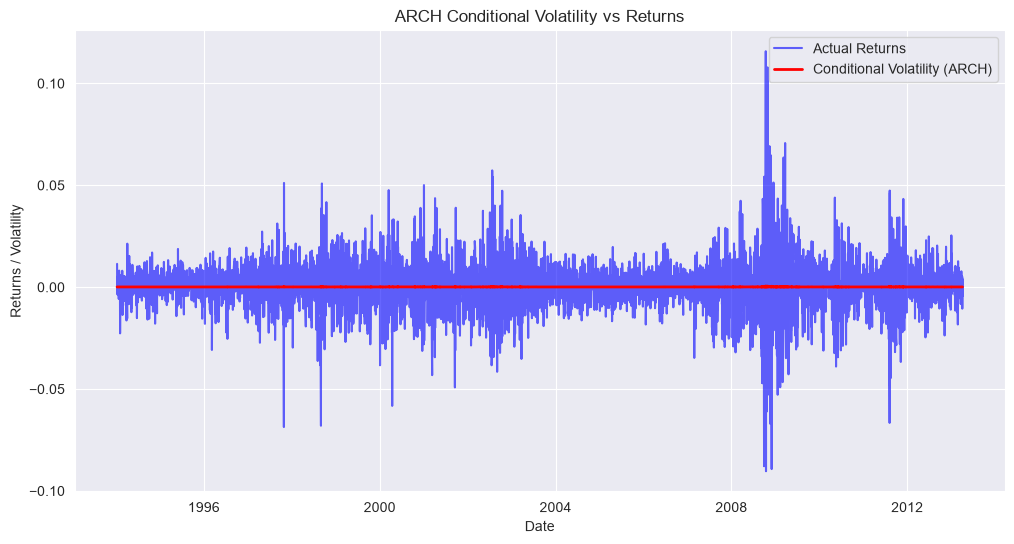

In [118]:
plt.figure(figsize=(12,6))

# Actual returns
plt.plot(returns.index, returns, label='Actual Returns', color='blue', alpha=0.6)

# Conditional volatility from ARCH(1) — divide by 100 to undo the *100 rescale used when fitting
cond_vol = results_arch.conditional_volatility / 100

plt.plot(cond_vol.index, cond_vol, label='Conditional Volatility (ARCH)', color='red', linewidth=2)

plt.title('ARCH Conditional Volatility vs Returns')
plt.xlabel('Date')
plt.ylabel('Returns / Volatility')
plt.legend()
plt.grid(True)
plt.show()

**Insights:** The red line shows how the model's expected volatility changes day to day — it spikes around turbulent periods (e.g. 2008, 2011) and subsides during calm ones. It lags the actual regimes by one day because ARCH(1) only reacts to yesterday's squared shock; a GARCH model would give smoother, more persistent volatility.